# Homework 2: Regression

Questions: [ML Zoomcamp 2026 – Homework 2](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/cohorts/2026/homework/02-regression/homework.md)

Dataset: [2026 Car Fuel Efficiency](https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv)

Goal: predict `fuel_efficiency_mpg` with linear regression.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## Preparing the dataset

Use only `engine_displacement`, `horsepower`, `vehicle_weight`, `model_year` and `fuel_efficiency_mpg`.

In [2]:
features = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
target = "fuel_efficiency_mpg"

df = pd.read_csv("data/car_fuel_efficiency_2026.csv")
df = df[features + [target]]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA

Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

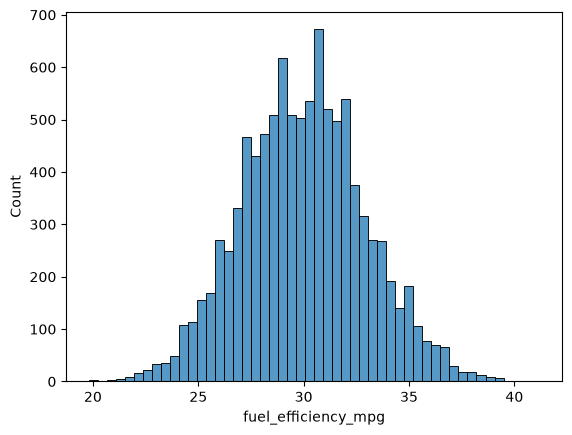

In [3]:
sns.histplot(df[target], bins=50)
plt.show()

In [4]:
df[target].describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

**Answer:** No. The distribution is roughly symmetric around 30 mpg (mean ≈ median ≈ 30), so unlike the lecture's car prices it doesn't need a log transformation. The models below use the raw target.

## Q1. Missing values

There's one column with missing values. What is it?

- `engine_displacement`
- `horsepower`
- `vehicle_weight`
- `model_year`

In [5]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

**Answer:** `horsepower`

## Q2. Median horsepower

What's the median (50% percentile) for variable `horsepower`?

- 204
- 254
- 304
- 354

In [6]:
df["horsepower"].median()

np.float64(254.0)

**Answer:** 254

## Prepare and split the dataset

60% / 20% / 20% train/validation/test split, exactly as in the lecture.

In [7]:
def split(df, seed=42):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test


def prepare_X(df, fill_value=0):
    return df[features].fillna(fill_value).values


def train_linear_regression(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T @ X
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv @ X.T @ y
    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))

In [8]:
df_train, df_val, df_test = split(df, seed=42)
y_train = df_train[target].values
y_val = df_val[target].values

len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

## Q3. Filling missing values

Fill `horsepower` with 0 or with the mean (computed on the training set only), train a linear regression without regularization, and compare validation RMSE rounded to 3 decimals.

- With 0
- With mean
- Both are equally good

In [9]:
hp_mean = df_train["horsepower"].mean()

for name, fill_value in [("With 0", 0), ("With mean", hp_mean)]:
    w0, w = train_linear_regression(prepare_X(df_train, fill_value), y_train)
    y_pred = w0 + prepare_X(df_val, fill_value) @ w
    print(f"{name}: {round(rmse(y_val, y_pred), 3)}")

With 0: 2.205
With mean: 2.202


**Answer:** With mean (2.202 vs 2.205)

## Q4. Regularization

Fill NAs with 0 and try `r` in `[0, 0.01, 0.1, 1, 5, 10, 100]`. Round validation RMSE to 4 decimals. If there's a tie, pick the smallest `r`.

In [10]:
X_train = prepare_X(df_train)
X_val = prepare_X(df_val)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression(X_train, y_train, r=r)
    print(f"r={r}: {round(rmse(y_val, w0 + X_val @ w), 4)}")

r=0: 2.2053
r=0.01: 2.2058
r=0.1: 2.2241
r=1: 2.3492
r=5: 2.4094
r=10: 2.4195
r=100: 2.4292


**Answer:** 0 (2.2053)

## Q5. Seed influence

For seeds 0–9: split 60/20/20, fill NAs with 0, train without regularization, and record validation RMSE. What's the standard deviation of the scores (rounded to 3 decimals)?

- 0.006
- 0.016
- 0.029
- 0.036

In [11]:
scores = []
for seed in range(10):
    df_tr, df_v, _ = split(df, seed=seed)
    w0, w = train_linear_regression(prepare_X(df_tr), df_tr[target].values)
    scores.append(rmse(df_v[target].values, w0 + prepare_X(df_v) @ w))

np.round(scores, 4), round(np.std(scores), 3)

(array([2.2392, 2.2021, 2.1634, 2.2044, 2.2019, 2.2458, 2.2697, 2.1908,
        2.2166, 2.207 ]),
 np.float64(0.029))

**Answer:** 0.029

## Q6. Test RMSE

Split with seed 9, combine train and validation, fill NAs with 0, train with `r=0.001`. What's the RMSE on the test set?

- 0.236
- 2.236
- 22.10
- 221.0

In [12]:
df_train, df_val, df_test = split(df, seed=9)
df_full_train = pd.concat([df_train, df_val])

w0, w = train_linear_regression(prepare_X(df_full_train), df_full_train[target].values, r=0.001)
round(rmse(df_test[target].values, w0 + prepare_X(df_test) @ w), 3)

np.float64(2.236)

**Answer:** 2.236

## Summary

| Question | Answer |
|---|---|
| EDA. Long tail? | No |
| Q1. Column with missing values | `horsepower` |
| Q2. Median horsepower | 254 |
| Q3. Better fill option | With mean |
| Q4. Best `r` | 0 |
| Q5. Std of seed scores | 0.029 |
| Q6. Test RMSE | 2.236 |